# Your First Machine Learning Models
### How to build them scikit-learn

This notebook is being presented for a tutorial at PyCon 2026. It will cover the fundamentals of machine learning and all of the key steps and code to building, scoring, and tuning machine learning models in scikit-learn. This notebook is authored by Corey Wade, Berkeley Coding Academy.

# Linear Regression

The first model we will use is Linear Regression. First, we need to access some data. Then we need to find one column from the data that may be predicted from the other columns. We call this special column, what we want to predict in the future, y. The way Linear Regression works is that every other column gets a weight, a multiplier, that is summed with all the other columns * weights with the goal of getting as close as possible to y.

Machine Learning happens when the algorithm finds the best possible weights, the multipliers, and returns a mathematical model. The mathematical model takes each column of data as its input, the X values, and what it is trying to predict, what we designate as y, as the output. It's a challenging problem because there are so many rows of data. The same model is used on all the rows. The predictions may work well on some rows, and not as well on other rows. After finding a model, we need to score it, to see how well it performed.

We will download the data directly from the folder, but here is the url where the data is stored - you can access directly from a raw csv file in github via a url as well: https://media.githubusercontent.com/media/PacktPublishing/Hands-On-Gradient-Boosting-with-XGBoost-and-Scikit-learn/refs/heads/master/Chapter02/bike_rentals_cleaned.csv

In [ ]:
# Load provided data (raw CSV file) and show first five rows
import pandas as pd
from rich import print

df = pd.read_csv("bike_rentals_cleaned.csv")
df.head()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1.0,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1.0,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1.0,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1.0,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1.0,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600


In [ ]:
# Learn more about the data including columnn types and non-vull values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   season      731 non-null    float64
 2   yr          731 non-null    float64
 3   mnth        731 non-null    float64
 4   holiday     731 non-null    float64
 5   weekday     731 non-null    float64
 6   workingday  731 non-null    float64
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  cnt         731 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 74.4 KB


To frame a machine learning problem, think about what would be interesting to predict from the data. For the dataset at hand, it would be interesting to predict the number of bike rentals on a given day, provided that you know the weather and the day of the week. You must have access to the data that you are trying to predict in advance for all supervised learning problems. The model needs data to train on, or to learn from. The idea here is that we are going to create a mathematical model when we have all of the data, and we are going to use that model to make predictions when we only have some of the data.

In [ ]:
# Split the data into X, the input to the function, and y, the output, what you are trying to predict
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [ ]:
# Verify that y is the bike rental counts, what we are trying to predict
print(X.columns, y.name)


Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='str') cnt

In [ ]:
# Build and score a Linear Regression Model using the scikit-learn library
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

lr = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
root_mean_squared_error(y_test, lr.predict(X_test))


824.3257394966785

In [ ]:
lr.score(X_test, y_test)


0.8305404308921018

In [ ]:
# Compare against a DummyRegressor baseline (predicts the mean)
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_rmse = root_mean_squared_error(y_test, dummy.predict(X_test))
lr_rmse = root_mean_squared_error(y_test, lr.predict(X_test))

print(f"Dummy RMSE:            {dummy_rmse:.2f}")
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Improvement:            {((dummy_rmse - lr_rmse) / dummy_rmse) * 100:.1f}%")


Dummy RMSE:            2022.17

Linear Regression RMSE: 824.33

Improvement:            59.2%

In [ ]:
# Get the weights! (Also called the multipliers, or coefficients)
print(lr.coef_)


[   -6.37930759   522.78682854  4354.91682042   156.03164006
  -391.94996801    73.1890088    163.1329618   -643.16961878
  2218.02136939  3336.26927214  -811.8849549  -2063.69366   ]

In [ ]:
# Make predictions! We will take the last five rows since they are properly formatted
lr.predict(X.tail())


array([2488.93628337, 3101.46364812, 2894.83617362, 2814.05020041,
       2449.40997552])

In [ ]:
# Compare predictions with actual values


Before finding better models to predict bike rentals, let's consider another type of machine learning problem.

# Logistic Regression

Classification is another type of Machine Learning problem. Instead of trying to get as close as possible to a correct numerical value, as in Linear Regression, you might want to classify data into two or more groups. The question here is a yes/no type of question. Does the patient have a heart disease? Yes or no? It's standard that 1 is yes, and 2 is no. To correctly predict this type of problem we need a different type of model, one that classifies data into two or more groups. Logistic Regression is one such model.

Logistic Regression is similar to Linear Regression. It takes all of the X values as input, finds weights for the values, and sums them together. But at the very end, the numerical value is placed into the sigmoid equation which is an elongated S-curve between 0 and 1 (See wikipedia entry: https://en.wikipedia.org/wiki/Sigmoid_function). If it's closer to 1, the row is classified as a 1, and if it's closer to 0, the row is classified as a 0.

Let's look at a dataset that requires classification. Here is the url: https://media.githubusercontent.com/media/PacktPublishing/Hands-On-Gradient-Boosting-with-XGBoost-and-Scikit-learn/refs/heads/master/Chapter02/heart_disease.csv

In [ ]:
# Load and show heart disease dataset
df_heart = pd.read_csv("heart_disease.csv")
df_heart.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Split data into X and y - target, is 1 if they have a heart disease, 0 otherwise
X = df_heart.iloc[:, :-1]
y = df_heart.iloc[:, -1]


In [ ]:
# Build and score a Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lor.fit(X_train, y_train)
lor.score(X_test, y_test)


0.8688524590163934

In [ ]:
# Check weights
lor.coef_


array([[-0.00698672, -1.41176661,  0.7924469 , -0.01594233, -0.00292725,
         0.16719581,  0.48107517,  0.01886731, -0.94942864, -0.64556634,
         0.63219779, -0.77570903, -0.91651619]])

In [ ]:
# Select row to predict and modify the values - what does it take for a patient to get a healthy heart?
lor.predict([[36, 1, 2, 110, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])


array([1])

In [ ]:
# Silence warnings (change to 'default' to bring warnings back)
import warnings

warnings.filterwarnings("ignore")


In [ ]:
# Show the probabilities of the prediction
lor.predict_proba([[36, 1, 2, 110, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])


array([[0.24225278, 0.75774722]])

# Tree-based Models

Now let's try a stronger model on our original dataset, a Decision Tree. A Decision Tree splits the data multiple times in an effort to find the desired y-value during training, like the game 20 questions. For instance, a Decision Tree might conclude that if it's a summer weekday and the temperature is above 70 degrees F and less than 80 degrees F and it is not a holiday then the company can expect 2100 bike rentals (made up example). Let's try a Decision Tree on the actual dataset and see how it performs.

In [ ]:
# Build and score Decision Tree
from sklearn.tree import DecisionTreeRegressor

df_bike = pd.read_csv("bike_rentals_cleaned.csv")
X = df_bike.iloc[:, :-1]
y = df_bike.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [ ]:
# Split data into a training and test set
dt.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [ ]:
# Fit model on training set, and score on test set
dt.score(X_test, y_test)


0.8337995608558522

In [ ]:
from sklearn.tree import export_text

print(export_text(dt, feature_names=list(X.columns), max_depth=3))


|--- instant <= 431.00
|   |--- instant <= 106.50
|   |   |--- atemp <= 0.43
|   |   |   |--- instant <= 70.50
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- instant >  70.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- atemp >  0.43
|   |   |   |--- mnth <= 3.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- mnth >  3.50
|   |   |   |   |--- truncated branch of depth 6
|   |--- instant >  106.50
|   |   |--- atemp <= 0.46
|   |   |   |--- atemp <= 0.29
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- atemp >  0.29
|   |   |   |   |--- truncated branch of depth 13
|   |   |--- atemp >  0.46
|   |   |   |--- hum <= 0.85
|   |   |   |   |--- truncated branch of depth 19
|   |   |   |--- hum >  0.85
|   |   |   |   |--- truncated branch of depth 10
|--- instant >  431.00
|   |--- temp <= 0.42
|   |   |--- instant <= 721.50
|   |   |   |--- hum <= 0.82
|   |   |   |   |--- truncated branch of depth 15
|   |   |   |--- hum >  0.82
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- instant >  721.50
|   |   |   |--- hum <= 0.66
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- hum >  0.66
|   |   |   |   |--- truncated branch of depth 4
|   |--- temp >  0.42
|   |   |--- hum <= 0.74
|   |   |   |--- windspeed <= 0.29
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- windspeed >  0.29
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- hum >  0.74
|   |   |   |--- windspeed <= 0.17
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- windspeed >  0.17
|   |   |   |   |--- truncated branch of depth 8

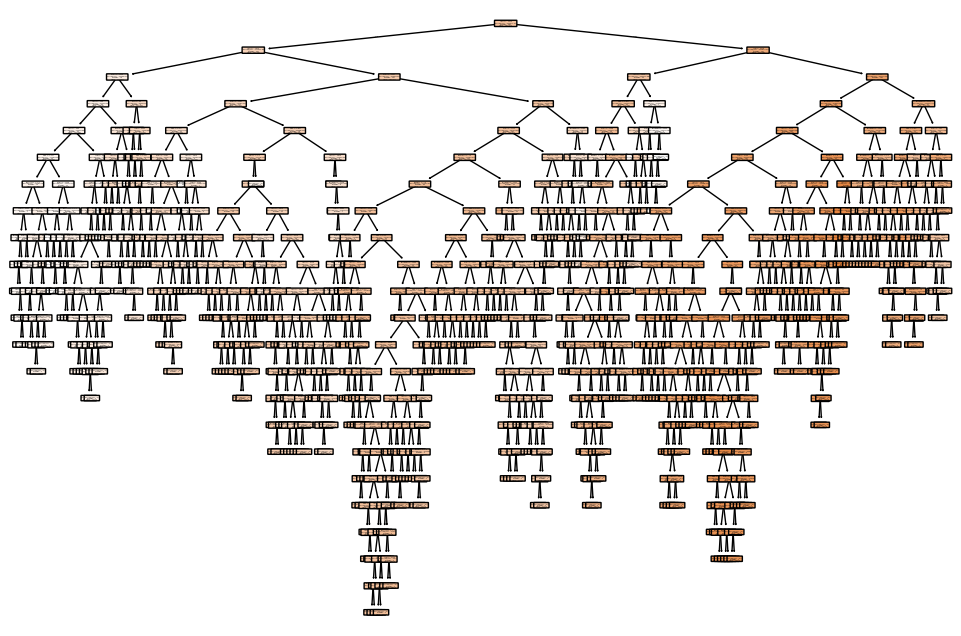

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    dt,
    feature_names=X.columns.values,
    filled=True,
    rounded=True,
)
plt.show()


By modifying max_depth, you can improve the test score. If you run the above cell multiple times, you keep getting different scores. There is some randomness in Decision Trees choosing their splits. How can we steady these predictions? One idea is to build multiple Decision Trees and take their average. This is called a Random Forest.

In [ ]:
# Build and score Random Forest with max_depth and n_estimators
dt = DecisionTreeRegressor(random_state=42, max_depth=5, criterion="friedman_mse")
dt.fit(X_train, y_train)
dt.score(X_test, y_test)


0.8163089153892822

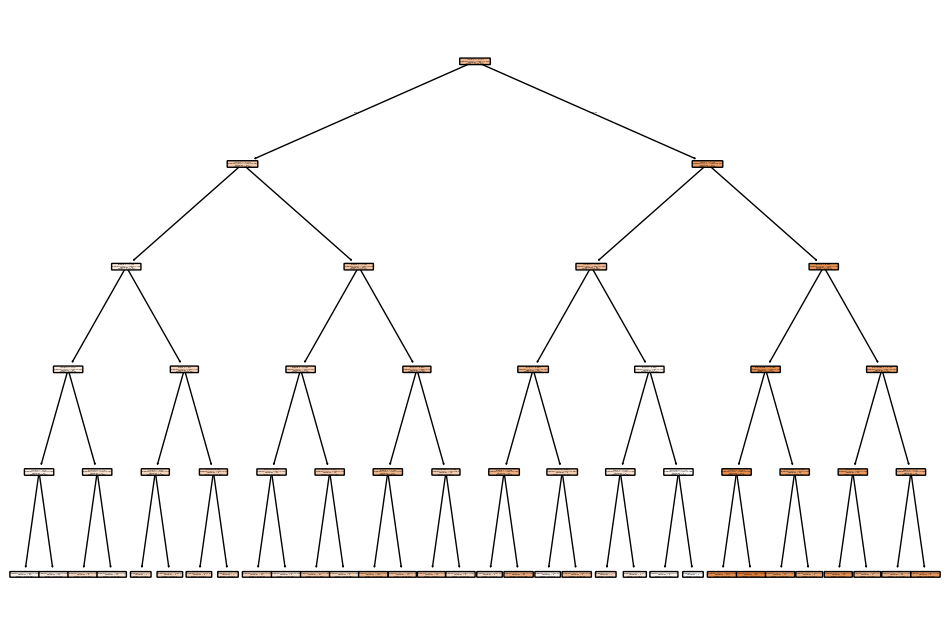

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(
    dt,
    feature_names=X.columns.values,
    filled=True,
    rounded=True,
)
plt.show()


Another idea is to build Decision Trees sequentially and to train on the errors of the previous model. This is called Gradient Boosting, and is one of the top ML algorithms for supervised learning, along with Random Forests.

In [ ]:
# Build and score Gradient Boosting Model
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42, max_depth=5, n_estimators=100)
gbr.fit(X_train, y_train)
gbr.score(X_test, y_test)


0.8936473699263181

# Challenge 1

Can you build a score a machine learning models on the heart disease dataset? Note that nearly every regressor, like the DecisionTreeRegressor, has a DecisionTreeClassifier. Try scoring some models in the cells below.

In [ ]:
# Build and score Decision Tree on Heart Disease Dataset
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

df_heart = pd.read_csv("heart_disease.csv")
X = df_heart.iloc[:, :-1]
y = df_heart.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dtc = DecisionTreeClassifier(random_state=42, max_depth=6)
# dtc.fit(X_train, y_train)
# dtc.score(X_test, y_test)

gscv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [3, 6, 9],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=5,
    refit=True,
).fit(X_train, y_train)


In [ ]:
gscv.best_estimator_


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
gscv.best_estimator_.score(X_test, y_test)


0.8360655737704918

In [ ]:
# Build and score Random Forest on Heart Disease Dataset
from sklearn.ensemble import RandomForestClassifier

rf_clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "max_depth": [3, 6, 9],
        "criterion": ["gini", "entropy", "log_loss"],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=5,
    refit=True,
).fit(X_train, y_train)


In [ ]:
rf_clf.best_estimator_.score(X_test, y_test)


0.8852459016393442

In [ ]:
# Build and score Gradient Boosting model on Heart Disease Dataset
from sklearn.ensemble import GradientBoostingClassifier

rf_clf = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "max_depth": [3, 6, 9],
        "criterion": ["friedman_mse", "squared_error", "mse"],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=5,
    refit=True,
).fit(X_train, y_train)


In [ ]:
rf_clf.best_estimator_.score(X_test, y_test)


0.8360655737704918

# Cross-validation and Scoring Metrics

Another place of randomness is train_test_split. Rerun it above and the following code and see what happens. The test set seems to hold a lot of importance. Is holding back one test set really the best approach?

In Machine Learning, it is standard to hold back a test set until the very end after fine-tuning and finalizing a model. In the meantime, it's preferrable to have another validation set that we can use to validate how well the model performs on unseen data when we make changes to the parameters with the goal of improving the model. We want to be able to experiment without compromising the test set. 

An optimal solution is to use cross-validation (See https://en.wikipedia.org/wiki/Cross-validation_(statistics)#/media/File:K-fold_cross_validation_EN.svg), a technique that will split our training data into 5 or more (sometimes less) different validation sets. Then we can score the model 5 different times, on the 5 different test sets, and take the average of these test sets to get a better idea of how the model performs. Note that the each time there is a new test set, a new 20% of the data is selected, and the remaining 80% is held back as the new training data. By using cross-validation we are not as dependent upon what portion of the data is held back as our validation set.

In [ ]:
# Peform cross-validation on a Random Forest
from re import S

from sklearn.model_selection import cross_val_score, cross_validate
import numpy as np

df_heart = pd.read_csv("heart_disease.csv")
df_heart.head()
X = df_heart.iloc[:, :-1]
y = df_heart.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_rgr = RandomForestRegressor(random_state=42, max_depth=6)

cross_val_score(rf_clf, X_train, y_train)


array([0.69387755, 0.79591837, 0.75      , 0.8125    , 0.79166667])

In [ ]:
results = cross_validate(
    estimator=rf_rgr,
    X=X,
    y=y,
    cv=5,
    scoring=["r2", "neg_root_mean_squared_error"],
    return_train_score=True,
    return_estimator=True,
    return_indices=True,
)

# ── What you get back ──────────────────────────────────────────────
print("Keys:", list(results.keys()))

# ── Multiple metrics at once ───────────────────────────────────────
for metric in ["r2", "neg_root_mean_squared_error"]:
    test = results[f"test_{metric}"]
    train = results[f"train_{metric}"]
    print(
        f"{metric:>30s}  train={train.mean():.4f}  test={test.mean():.4f}  "
        f"gap={train.mean() - test.mean():.4f}"
    )

# ── Timing ─────────────────────────────────────────────────────────
print(f"\nMean fit time:   {np.mean(results['fit_time']):.3f}s")
print(f"Mean score time: {np.mean(results['score_time']):.3f}s")

# ── Fitted estimators (one per fold) ──────────────────────────────
best_fold = np.argmax(results["test_r2"])
best_model = results["estimator"][best_fold]
print(f"\nBest fold: {best_fold}, R²: {results['test_r2'][best_fold]:.4f}")
print(f"Best model feature importances shape: {best_model.feature_importances_.shape}")

# ── Fold indices ───────────────────────────────────────────────────
fold_0_train = results["indices"]["train"][0]
fold_0_test = results["indices"]["test"][0]
print(f"\nFold 0: {len(fold_0_train)} train samples, {len(fold_0_test)} test samples")


Keys:
[
    'fit_time',
    'score_time',
    'estimator',
    'indices',
    'test_r2',
    'train_r2',
    'test_neg_root_mean_squared_error',
    'train_neg_root_mean_squared_error'
]

r2  train=0.8864  test=0.0690  gap=0.8175

neg_root_mean_squared_error  train=-0.1630  test=-0.4288  gap=0.2658

Mean fit time:   0.053s

Mean score time: 0.004s

Best fold: 2, R²: 0.3449

Best model feature importances shape: (13,)

Fold 0: 242 train samples, 61 test samples

In [ ]:
rf_clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
rf_clf.score(X_test, y_test)


0.9672131147540983

In [ ]:
# Perform cross-validation on Gradient Boosting

gb_clf = GradientBoostingClassifier(random_state=42, max_depth=6)
cross_val_score(gb_clf, X_train, y_train, cv=5)
gb_clf.fit(X_train, y_train)
gb_clf.score(X_test, y_test)


0.7704918032786885

These scores are more robust as they have been performed on 5 different validation sets.

As a final adjustment in this section, let's take a look at changing the scoring metric. An R2 scoring metric leaves a lot to be desired. There are many scoring metrics to choose from. The root mean squared error is standard in regression models. It takes the square root of the sum of the squared errors of each prediction. The nice thing about the RMSE is that it's easier to interpret. It tells us how far off the predictions are on average from the expected value.

In [ ]:
# Use RMSE on Gradient Boosting
model = GradientBoostingRegressor()
# We first use the mean squared error - it's negative because sklearn scoring defaults are the higher the better
mse = cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=5)
rmse = (
    -mse
) ** 0.5  # make positive and take root for RMSE - closer to 0# Get descriptive stati
print(rmse)


[0.46876063 0.40835923 0.38422829 0.37221327 0.38116668]

We can now interpret the score much better. The model is off by this many bike rentals on average. Is this good or bad? Let's check against the standard deviation of the y-column.

In [ ]:
results = cross_validate(
    estimator=rf_rgr,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=["r2", "neg_root_mean_squared_error"],
    return_train_score=True,
    return_estimator=True,
)

# ── Multiple metrics at once ───────────────────────────────────────
for metric in ["r2", "neg_root_mean_squared_error"]:
    test = results[f"test_{metric}"]
    train = results[f"train_{metric}"]
    print(
        f"{metric:>30s}  train={train.mean():.4f}  test={test.mean():.4f}  "
        f"gap={train.mean() - test.mean():.4f}"
    )

# ── Timing ─────────────────────────────────────────────────────────
print(f"\nMean fit time:   {np.mean(results['fit_time']):.3f}s")
print(f"Mean score time: {np.mean(results['score_time']):.3f}s")

# ── Best fold by R² ───────────────────────────────────────────────
best_fold = np.argmax(results["test_r2"])
best_model = results["estimator"][best_fold]
print(f"\nBest fold: {best_fold}, R²: {results['test_r2'][best_fold]:.4f}")


r2  train=0.8985  test=0.4348  gap=0.4637

neg_root_mean_squared_error  train=-0.1584  test=-0.3700  gap=0.2116

Mean fit time:   0.046s

Mean score time: 0.004s

Best fold: 3, R²: 0.5802

# Fine-tuning models

Now let's go through the whole process and fine-tune a model. The idea of fine-tuning a model is choosing optimal parameters to give the best possible predictions based on the question at hand. Let's return to the heart disease data. Let's say that we want to screen patients who may be at risk of heart disease. This is very different than trying to make an accurate determination if someone has a heart disease. The latter is called precision, and the former is called recall. (See https://en.wikipedia.org/wiki/Precision_and_recall)

Another issue to consider with classification is the percentage of positive cases. It's helpful to train a model with the same number of positive cases in all splits. An imbalance in splits can lead to very low scores due to limited data. (Note that outliers can be removed in advance as part of the data-cleaning process.)

Let's split the data evenly, and learn about the precision and recall using a Confusion Matrix and Classification Report.

In [ ]:
# Load heart disease data for fine-tuning
df_heart = pd.read_csv("heart_disease.csv")
X2 = df_heart.iloc[:, :-1]
y2 = df_heart.iloc[:, -1]

# Split classification data - use a random state for consistency
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, random_state=0)
# Stratify the data, which means keep it balanced
from sklearn.model_selection import StratifiedKFold

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


In [ ]:
# Show confusion matrix and classification report for details on precision/recall
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)
model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_test)
print(confusion_matrix(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))


[[24  9]
 [ 6 37]]

precision    recall  f1-score   support

           0       0.80      0.73      0.76        33
           1       0.80      0.86      0.83        43

    accuracy                           0.80        76
   macro avg       0.80      0.79      0.80        76
weighted avg       0.80      0.80      0.80        76

You interpret the top matrix as correct along the diagonals. The scores are shown above. Note that the positive cases, the 1s, the patients with heart diseases, have a different precision and recall than patients with 0s, the healthy ones. The f1-score is a harmonic balance between precision and recall. Let's work on recall, flagging patients for heart diseases, and optimize parameters to get the best possible recall.

In [ ]:
# GridSearchCV searches all possible parameters and chooses the combinations with the best score
from sklearn.model_selection import GridSearchCV


# Here is a customized function to find the best scores - note the scoring is recall, and cv is skfold as defined earlier.
def grid_search(params, clf=model):
    grid_clf = GridSearchCV(clf, params, scoring="recall", cv=skfold)
    grid_clf.fit(X2_train, y2_train)
    best_params = grid_clf.best_params_
    print("Best params:", best_params)
    best_score = grid_clf.best_score_
    print("Best score:", best_score)


In [95]:
# We start by modifying just max_depth, and n_estimaters - it will search  6*3=18 different combinations
model = GradientBoostingClassifier(random_state=0)
grid_search(
    {"max_depth": [1, 2, 3, 4, 6, 8], "n_estimators": [50, 100, 200]}
)  # with an average of 100 trees - this is 18*100=1800 ML models being built!


Best params:
{'max_depth': 1, 'n_estimators': 50}

Best score: 0.8766666666666666

WARNING - You must be carefuly when using GridSearchCV. This code ran fairly quickly because our dataset is super small. GridSearchCV can be very time consuming. A nice alternative is to use RandomizedSearchCV. It will randomly check 10 or any other combinations that you want. When starting with a larger range of parameters, this is usually a better option.

In [ ]:
# RandomizedSearchCV works the same way as GridSearchCV, but checks n (10 by default) random combinations
from sklearn.model_selection import RandomizedSearchCV


def random_search(params, clf=model):
    grid_clf = RandomizedSearchCV(
        clf, params, scoring="recall", cv=skfold, n_iter=10, random_state=0
    )
    grid_clf.fit(X2_train, y2_train)
    best_params = grid_clf.best_params_
    print("Best params:", best_params)
    best_score = grid_clf.best_score_
    print("Best score:", best_score)
    return grid_clf


In [97]:
# the following is a reasonable starting sample of params for a randomized search
model = GradientBoostingClassifier(random_state=0)
random_search(
    params={
        "subsample": [
            0.4,
            0.5,
            0.6,
            0.7,
            0.8,
            0.9,
            1,
        ],  # percentage of rows to use per tree
        "min_samples_split": [
            2,
            3,
            4,
            5,
            6,
            7,
            8,
        ],  # number of rows required before a split must be made
        "learning_rate": [
            0.001,
            0.01,
            0.1,
            0.2,
            0.4,
            0.6,
        ],  # rate at which model "learns", how quickly it steps toward minimum errors
        "max_depth": [1, 2, 3, 4, 5, 6, 8, 10],  # number of splits the tree makes
        #'n_estimators':[25, 50, 100, 200, 400] # n_estimators, total number of trees, is often better used later
    }
)


Best params:
{'subsample': 0.8, 'min_samples_split': 6, 'max_depth': 6, 'learning_rate': 0.001}

Best score: 0.9833333333333334

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.001, 0.01, ...], 'max_depth': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'subsample': [0.4, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [98]:
# Narrow down the parameters and try again
model = GradientBoostingClassifier(random_state=0)
rs = random_search(
    params={
        "subsample": np.arange(0.75, 0.85, 0.1),  # percentage of rows to use per tree
        # percentage of rows to use per tree
        "learning_rate": np.arange(
            0.001 / 2, 0.001 * 1.6, 0.001 / 10
        ),  # rate at which model "learns", how quickly it steps toward minimum errors
        "max_depth": [5, 7, 0.1],  # number of splits the tree makes
        #'n_estimators':[25, 50, 100, 200, 400] # n_estimators, total number of trees, is often better used later
    }
)


Best params:
{'subsample': np.float64(0.75), 'max_depth': 7, 'learning_rate': np.float64(0.0008000000000000001)}

Best score: 0.9916666666666666

Any concerns about the score may be clarified with the confusion matrix and classification report.

In [ ]:
rs.best_estimator_.score(X2_test, y2_test)


0.7368421052631579

In [ ]:
# Show confusion matrix and classification report


Let's modify our search using the f1-score instead. Recall that f1 is the harmonic balance between precision and recall.

In [ ]:
# Combine functions into one with f1 scoring as default parameter
def params_search(
    params, clf=GradientBoostingClassifier(random_state=0), random=False, scoring="f1"
):
    if random:
        grid_clf = RandomizedSearchCV(
            clf, params, scoring=scoring, cv=skfold, n_iter=10, random_state=0
        )
    else:
        grid_clf = GridSearchCV(clf, params, scoring="f1", cv=skfold)
    grid_clf.fit(X2_train, y2_train)
    best_params = grid_clf.best_params_
    print("Best params:", best_params)
    best_score = grid_clf.best_score_
    print("Best score:", best_score)


In [102]:
# Search params using f1-score
params_search(
    random=True,
    params={
        "subsample": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        "min_samples_split": [2, 3, 4, 5, 6, 7, 8],
        "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.4, 0.6],
        "max_depth": [1, 2, 3, 4, 5, 6, 8, 10],
        #'n_estimators':[25, 50, 100, 200, 400]
    },
)


Best params:
{'subsample': 0.4, 'min_samples_split': 6, 'max_depth': 10, 'learning_rate': 0.01}

Best score: 0.845245636329445

In [103]:
# Narrow params around best: subsample=0.4, min_samples_split=6, max_depth=10, learning_rate=0.01
params_search(
    random=True,
    params={
        "subsample": [0.3, 0.4, 0.5],
        "min_samples_split": [4, 5, 6, 7, 8],
        "learning_rate": [0.005, 0.01, 0.02, 0.05],
        "max_depth": [8, 10, 12, 15],
    },
)


Best params:
{'subsample': 0.4, 'min_samples_split': 7, 'max_depth': 12, 'learning_rate': 0.05}

Best score: 0.8507441252476319

In [104]:
# Narrow params further: subsample=0.4, min_samples_split=7, max_depth=12, learning_rate=0.05
params_search(
    random=True,
    params={
        "subsample": [0.35, 0.4, 0.45],
        "min_samples_split": [6, 7, 8],
        "learning_rate": [0.03, 0.04, 0.05, 0.06, 0.07],
        "max_depth": [10, 11, 12, 13, 14],
    },
)


Best params:
{'subsample': 0.35, 'min_samples_split': 8, 'max_depth': 13, 'learning_rate': 0.06}

Best score: 0.8470588149392135

In [105]:
# Check all values with gridsearch
params_search(
    random=False,
    params={
        "subsample": [0.35, 0.4, 0.45],
        "min_samples_split": [6, 7, 8],
        "learning_rate": [0.03, 0.04, 0.05, 0.06, 0.07],
        "max_depth": [10, 11, 12, 13],
    },
)


Best params:
{'learning_rate': 0.05, 'max_depth': 10, 'min_samples_split': 6, 'subsample': 0.4}

Best score: 0.8574910803482233

In [106]:
# Add n_estimators with best params locked in
params_search(
    random=False,
    params={
        "subsample": [0.4],
        "min_samples_split": [6],
        "learning_rate": [0.05],
        "max_depth": [10],
        "n_estimators": [50, 100, 200, 300, 400],
    },
)


Best params:
{'learning_rate': 0.05, 'max_depth': 10, 'min_samples_split': 6, 'n_estimators': 100, 'subsample': 0.4}

Best score: 0.8574910803482233

In [107]:
# Narrow params - fine-tune n_estimators around 100
params_search(
    random=False,
    params={
        "subsample": [0.4],
        "min_samples_split": [6],
        "learning_rate": [0.05],
        "max_depth": [10],
        "n_estimators": [75, 100, 125, 150],
    },
)


Best params:
{'learning_rate': 0.05, 'max_depth': 10, 'min_samples_split': 6, 'n_estimators': 100, 'subsample': 0.4}

Best score: 0.8574910803482233

We could keep searching, but it could be that our model cannot improve upon this f1-score. Let's check this one in the confusion matrix and classification report.

In [ ]:
# Show confusion matrix and classification report with best f1 params
best_model = GradientBoostingClassifier(
    random_state=0,
    subsample=0.4,
    min_samples_split=6,
    learning_rate=0.05,
    max_depth=10,
    n_estimators=100,
)
best_model.fit(X2_train, y2_train)
y2_pred = best_model.predict(X2_test)
print(confusion_matrix(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))


[[25  8]
 [ 3 40]]

precision    recall  f1-score   support

           0       0.89      0.76      0.82        33
           1       0.83      0.93      0.88        43

    accuracy                           0.86        76
   macro avg       0.86      0.84      0.85        76
weighted avg       0.86      0.86      0.85        76

This is an excellent recall score for the patients with heart disease. There is real value here. This model could potentially be used to help medical staff warn patients who may be at increased risk of heart disease. Now let's finalize the model.

# Challenge 2

1. See if you can find an optimal model that returns the best possible score for precision.
2. See if you can find an optimal model that minimizes the RMSE for bike rentals.

In [ ]:
def params_search(
    params,
    clf=GradientBoostingRegressor(random_state=0),
    random=False,
    scoring="precision",
):
    if random:
        grid_clf = RandomizedSearchCV(
            clf, params, scoring=scoring, cv=skfold, n_iter=10, random_state=0
        )
    else:
        grid_clf = GridSearchCV(clf, params, scoring=scoring, cv=skfold)
    grid_clf.fit(X2_train, y2_train)
    best_params = grid_clf.best_params_
    print("Best params:", best_params)
    best_score = grid_clf.best_score_
    print("Best score:", best_score)


In [110]:
# Search params using f1-score
params_search(
    random=True,
    params={
        "subsample": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        "min_samples_split": [2, 3, 4, 5, 6, 7, 8],
        "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.4, 0.6],
        "max_depth": [1, 2, 3, 4, 5, 6, 8, 10],
        "n_estimators": [25, 50, 100, 200, 400],
    },
)


Best params:
{'subsample': 0.6, 'n_estimators': 25, 'min_samples_split': 3, 'max_depth': 4, 'learning_rate': 0.01}

Best score: nan

In [ ]:
# Optimize model to find the best score for precision with the heart disease dataset


In [ ]:
# Optimize model to predict number of bike rentals here


# Finalize Model

Generally speaking, models are finalized when there will be no more training/testing in the foreseeable future. Obviously models can be retrained when more data comes in. A couple of helpful steps in finalizing models: 1) Convert data to numpy arrays to avoid the need of labels, and 2) Go back and train the model on all the data. Why? We are done training and testing. The more data, the better.

In [ ]:
# Convert data to numpy arrays
import numpy as np

X_np = np.array(X2)
y_np = np.array(y2)

# Train model on all data as numpy arrays
model = GradientBoostingClassifier()  # Fill in parentheses
model.fit()  # Fill in parentheses


In [ ]:
# Save models using pickle for future use
import pickle

# Save model to local machine
filename = "final_model.sav"
pickle.dump(model, open(filename, "wb"))

# Load the model from disk
load_model = pickle.load(open(filename, "rb"))

# Check model
print(load_model)


As a bonus, you can show how influential each column was when building the model using feature_importances_. This is very valuable information. 

In [ ]:
# Show the influence of each column
model.feature_importances_


In [ ]:
# Zip columns and feature_importances_ into dict for greater readability
feature_dict = dict(zip(X2.columns, model.feature_importances_))

import operator

# Sort dict by values (as list of tuples)
sorted(feature_dict.items(), key=operator.itemgetter(1), reverse=True)


That's all! Feel free to check out my youtube playlist on machine learning that goes into greater detail on some of this code: https://www.youtube.com/playlist?list=PL5Rqo-gm0HkbvqOy-OvHpBs3XHiA9QpIY